In [14]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import display
import ipywidgets as widgets
import pandas as pd
import sympy as sp
import scipy.stats as stats
import sympy as sp
import jax
import jax
import jax.numpy as jnp
from jax.scipy.special import ndtr
import os

import statsmodels


#%matplotlib ipympl




# VaR and CVaR

## What are we measuring?

**VaR (Value at Risk):** The minimum loss in the worst X% of scenarios.
> "With 95% confidence, I will not lose more than X in a single day."

**CVaR (Conditional VaR / Expected Shortfall):** The *average* loss in those worst X% scenarios.
> "When things go bad (worst 5%), my average loss will be X."

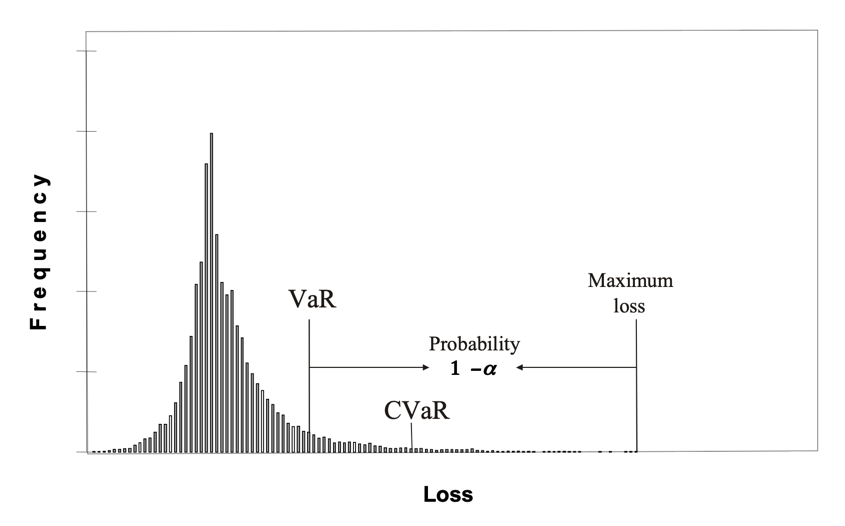

## Example

A USD 10M portfolio over a one-day horizon, at the **95% confidence level:**

**VaR = USD 500,000**

1. USD 500,000 is the minimum loss expected in the worst **5%** of days.
2. There is a **5%** chance of losing more than USD 500,000 in a single day.
3. On **95%** of days, losses will stay below USD 500,000.

**CVaR = USD 650,000**

1. On the worst **5%** of days, the **average** loss is USD 650,000.
2. When things go bad, expect to lose USD 650,000 on average  not just the USD 500,000 VaR threshold.
3. CVaR always exceeds VaR: USD 650,000 > USD 500,000, because it averages *all* losses beyond the threshold.

## Effect of Confidence Level

A USD 10M portfolio over a one-day horizon:

**VaR: USD 500,000 (95% confidence) | USD 700,000 (99% confidence)**

1. USD 500,000 is the minimum loss expected in the worst **5%** of days.
2. USD 700,000 is the minimum loss expected in the worst **1%** of days.
3. Higher confidence = larger VaR threshold ( guarding against rarer, more extreme events)

**CVaR: USD 650,000 (95% confidence) | USD 900,000 (99% confidence)**

1. In the worst **5%** of days, the average loss is USD 650,000.
2. In the worst **1%** of days, the average loss is USD 900,000.
3. Higher confidence = deeper into the tail ( CVaR captures increasingly severe scenarios.)

> **Key intuition:** raising confidence from 95% to 99% does not merely shift the threshold
> it narrows the focus to a smaller, more adverse segment of the loss distribution.


# Time Horizon


**Time horizon** is the future period VaR is predicting over, such as 1 day or 10 days.

**Estimation window** is the historical data used to calibrate the model
    * such as your 4-year daily return series used here


VaR and CVaR are always tied to a specific horizon, not just a confidence level. A 1-day VaR and a 10-day VaR for the same portfolio are different numbers, since losses can accumulate or offset over a longer window.

#### SRTR Square-root-of-time rule
As a rough approximation (assuming iid returns), VaR scales with the square root of time:

$$ 10-day VaR ≈ 1-day VaR × √10$$

### Example:

with %3,6 daily VaR:

"There is a 5% probability that I will lose more than 3.6% of my portfolio value over the next 1 day."

With STRTR:

$$\text{10-day VaR} \approx \text{1-day VaR} \times \sqrt{10} = 3.6\% \times 3.162 \approx 11.4\ $$

"There is a 5% probability that I will lose more than 11.4% of my portfolio value over the next 10 days."
"With 95% confidence, my loss over the next 10 days will not exceed 11.4%."



## Historical vs Parametric vs Simulated

### Historical
Computed directly from real past price data

- Answers: *"How did this portfolio actually behave in the past?"*
- Strength: captures real crises, fat tails, and market shocks
- Weakness: limited to however many trading days you have (~252/year)

### Parametric
Computed analytically using an assumed return distribution — typically **normal** or **Student's t** —
given historical mean (`mu`) and covariance (`cov`).

- Answers: *"What does theory predict, under a given distributional assumption?"*
- Strength: fast, closed-form — no simulation required
- Weakness: if the assumed distribution is misspecified, tail risk will be systematically under- or overestimated
  - Normal distribution: symmetric, thin tails,  tends to **underestimate** extreme losses
  - Student's t distribution: heavier tails, better captures rare, severe events

### Simulated (Monte Carlo)
Computed from thousands of synthetic scenarios generated from historical `mu` and `cov`.

- Answers: *"How could this portfolio behave in the future?"*
- Strength: 10,000+ scenarios, covers possibilities beyond what history recorded
- Weakness: output quality is contingent on the accuracy of the input parameters (`mu`, `cov`)


**If simulated VaR < historical VaR** → your model is underestimating real risk.
The normality assumption is too optimistic. Real return distributions exhibit heavier tails than the model assumes.

**If parametric VaR < historical VaR** → the same limitation applies, more severely.
Parametric VaR is the most restrictive: it imposes a symmetric bell curve on a distribution that is in practice skewed and fat-tailed.


## Mathematical Definition

1) **We are not working with returns $R$, we work with **losses** $L = -R$. **

A positive loss means the portfolio lost value. This way, "bad outcomes" are on the right side of the distribution — which makes the math cleaner.

2) **VaR is simply a quantile of the loss distribution** . At confidence level $\alpha = 0.95$:

$$\text{VaR}_{0.95} = F_L^{-1}(0.95)$$

Read this as: *"Find the loss value that 95% of all outcomes fall below."*
Equivalently, only the worst 5% of days produce a loss larger than this number.

3) **CVaR asks: given that we are already in that worst 5%, what is the average loss?**

$$\text{CVaR}_{0.95} = \mathbb{E}\left[ L \mid L \geq \text{VaR}_{0.95} \right]$$

The integral form below is just the formal way of writing "average over the tail":

$$\text{CVaR}_{0.95} = \frac{1}{0.05} \int_{\text{VaR}_{0.95}}^{\infty} l \cdot f_L(l) \, dl$$

You are averaging every possible loss beyond the VaR threshold, weighted by how likely each one is —
then scaling so the weights sum to 1 (that is what the $\frac{1}{0.05}$ does).

**Key property:** $\text{CVaR} \geq \text{VaR}$ always. VaR ONLY tells you where the tail begins.
CVaR tells you how bad it gets once you are inside it




/var/folders/2h/8jbngzys5690t1qxbcx36brh0000gn/T/ipykernel_60703/162064628.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/2h/8jbngzys5690t1qxbcx36brh0000gn/T/ipykernel_60703/162064628.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


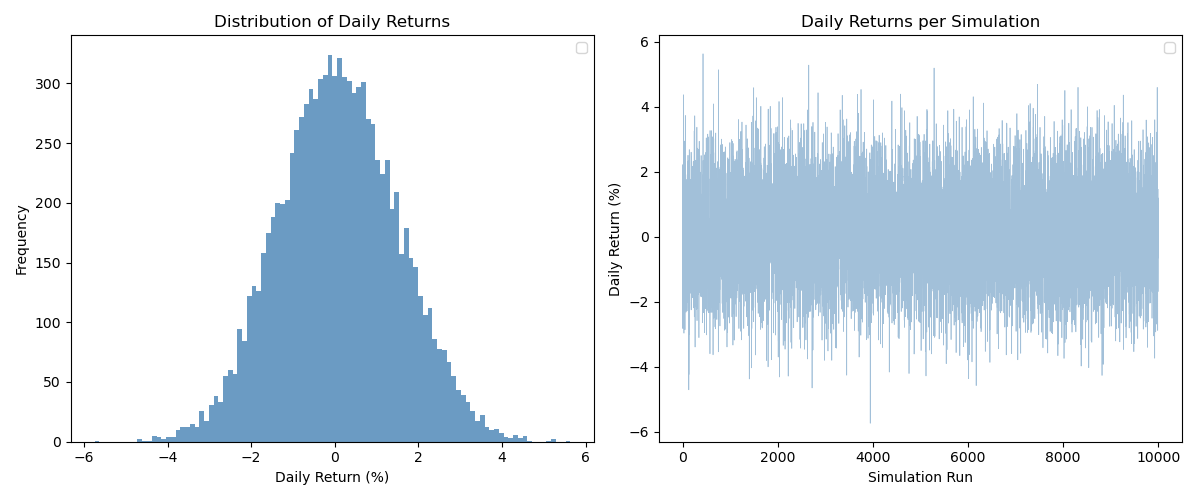

Mean return: 0.09%
Std:         1.43%
Simulating paths...


interactive(children=(IntSlider(value=0, description='Minute', max=1440), Output()), _dom_classes=('widget-int…

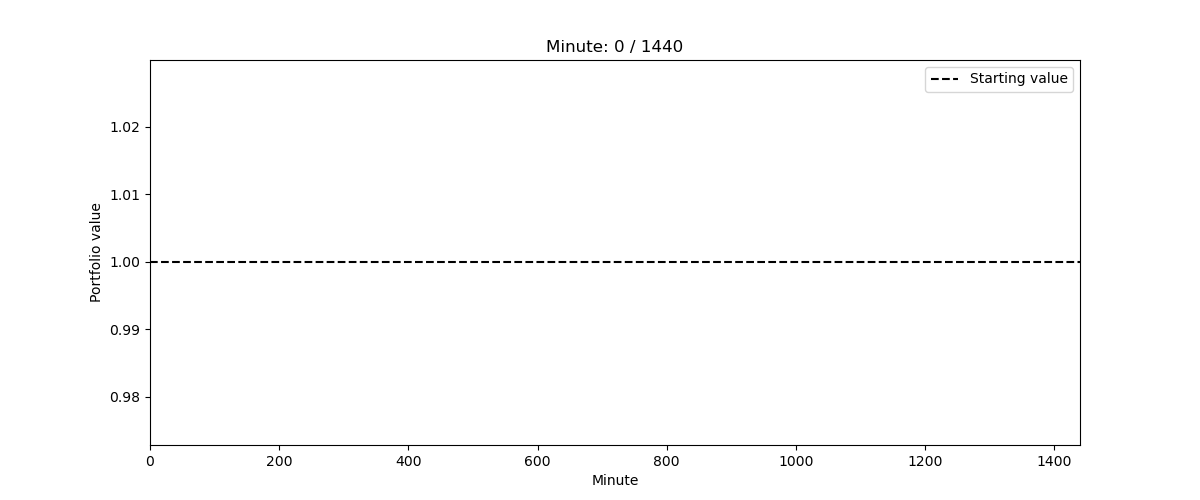

In [15]:
%run 02_monte_carlo.ipynb


In [16]:
confidence = 0.95
weights = [0.25, 0.25, 0.25, 0.25]

## Historical VAR/CVAR

In [17]:
returns


,AAPL,JPM,KO,XOM
Date,,,,
2020-01-03,-0.009722,-0.013197,-0.005456,-0.008039
2020-01-06,0.007968,-0.000795,-0.000366,0.007678
2020-01-07,-0.004703,-0.017001,-0.007682,-0.008184
2020-01-08,0.016087,0.007801,0.001843,-0.015080
2020-01-09,0.021241,0.003651,0.018215,0.007655
...,...,...,...,...
2024-12-24,0.011478,0.016444,0.007374,0.000941
2024-12-26,0.003176,0.003425,-0.004297,0.000846
2024-12-27,-0.013242,-0.008102,-0.001918,-0.000094


In [18]:
losses = - returns
losses
portfolio_losses =  losses @ weights

In [19]:
portfolio_losses

Date
2020-01-03    0.009103
2020-01-06   -0.003621
2020-01-07    0.009393
2020-01-08   -0.002663
2020-01-09   -0.012691
                ...   
2024-12-24   -0.009059
2024-12-26   -0.000788
2024-12-27    0.005839
2024-12-30    0.008605
2024-12-31   -0.003848
Length: 1257, dtype: float64

In [20]:
VAR = portfolio_losses.quantile(confidence)
VAR

np.float64(0.019031973808595875)

We have recieved an **daily** VaR of %1.9

## TIME HORIZON : 1 Day, DAILY

For an portfolio of USD 10M = ~190.000

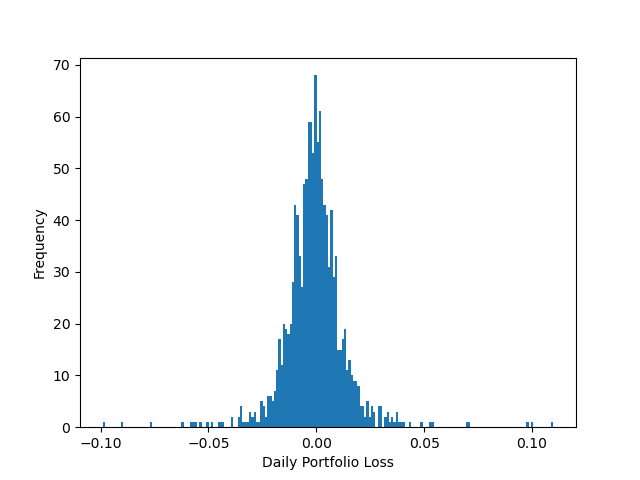

In [21]:
fig, ax = plt.subplots()
plt.hist(portfolio_losses, bins= 200)
ax.set_xlabel('Daily Portfolio Loss')
ax.set_ylabel('Frequency')
plt.show()

In [22]:
# for historical CVAR, we will find the values higher then VAR and get the average
days_which_lies_at_tail = portfolio_losses[portfolio_losses >= VAR ]

In [23]:
days_which_lies_at_tail

Date
2020-01-31    0.029835
2020-02-24    0.036459
2020-02-25    0.032748
2020-02-27    0.053379
2020-03-03    0.028666
                ...   
2023-03-15    0.021927
2024-04-12    0.020188
2024-08-05    0.026313
2024-09-10    0.024029
2024-12-18    0.019585
Length: 63, dtype: float64

In [24]:
historical_CVAR = days_which_lies_at_tail.mean()
historical_CVAR

np.float64(0.0336425735344844)

CVAR = %3.36

For an USD10M Portoflio:

VaR (95%) ≈ USD 190,000
CVaR (95%) ≈ USD 336,000



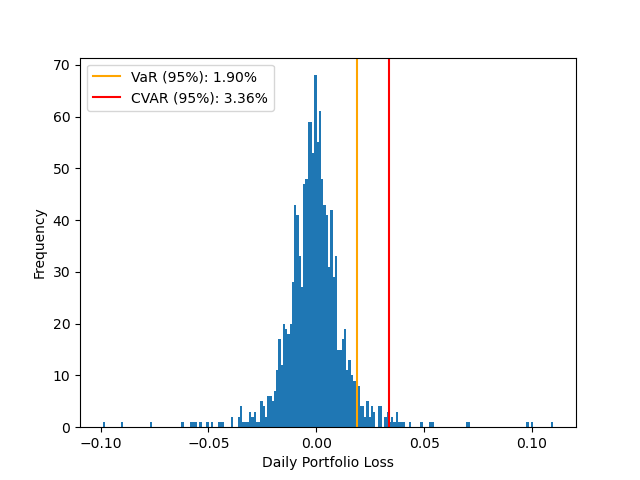

In [26]:
fig, ax = plt.subplots()
plt.hist(portfolio_losses, bins= 200)
ax.set_xlabel('Daily Portfolio Loss')
ax.set_ylabel('Frequency')
ax.axvline(VAR, color='orange', label=f'VaR (95%): {VAR:.2%}') # tail starts ater orange line
ax.axvline(historical_CVAR, color='red', label=f'CVAR (95%): {historical_CVAR:.2%}')
ax.legend() # to show labels
plt.show()

# Parametric VaR/CVaR

## Parametric Normal — VaR & CVaR

$$\text{VaR}_\alpha = -\mu_p + \sigma_p \cdot Z_\alpha$$

$$\text{CVaR}_\alpha = -\mu_p + \sigma_p \left[ \frac{\phi(Z_\alpha)}{1-\alpha} \right]$$

**Where:**

- $\mu_p$ = portfolio's expected daily return (`mu_vec @ weights`);
    - $-\mu_p$ is the expected daily loss (what we have been working with in historical)
- $\sigma_p$ = portfolio's daily standard deviation (`sqrt(weights @ e_cov @ weights)`)
    - $ecov$ = Covariance Matrix based on Returns
- $\alpha$ = confidence level (e.g. $0.95$)
- $Z_\alpha$ = standard normal quantile at $\alpha$ (`stats.norm.ppf(alpha)`, $\approx 1.645$ for 95%)
- $\phi(Z_\alpha)$ = standard normal **density** at $Z_\alpha$ (`stats.norm.pdf(Z_alpha)`)

**Intuition:**

VaR says: *"start from the expected loss, then move $Z_\alpha$ standard deviations into the tail."*
$Z_\alpha$ is a fixed number. At 95% confidence it's about 1.645, purely a property of the normal
distribution's shape.

CVaR replaces this single threshold with the **average position within the tail**:
$\dfrac{\phi(Z_\alpha)}{1-\alpha} = E[Z \mid Z \geq Z_\alpha]$, the expected value of a standard normal
variable given that it already exceeds $Z_\alpha$. Since this average is always larger than $Z_\alpha$
itself, $\text{CVaR}_\alpha \geq \text{VaR}_\alpha$ always holds.

## Parametric Student-t — VaR & CVaR

$$\text{VaR}_\alpha = -\mu_p + \sigma_p \cdot t_\alpha$$

$$\text{CVaR}_\alpha = -\mu_p + \sigma_p \cdot \frac{(\nu + t_\alpha^2)}{(\nu - 1)(1-\alpha)} \cdot f_\nu(t_\alpha)$$

**Where:**

- $\mu_p, \sigma_p$ = same as before, but `loc`/`scale` now come from `stats.t.fit(...)` instead of the sample mean/std
- $\nu$ (nu) = degrees of freedom — controls tail heaviness. Lower $\nu$ → fatter tails. As $\nu \to \infty$, the t-distribution converges to normal.
- $t_\alpha$ = standard t quantile at $\alpha$ (`stats.t.ppf(alpha, df=nu)`)
- $f_\nu(t_\alpha)$ = standard t **density** at $t_\alpha$ (`stats.t.pdf(t_alpha, df=nu)`)

**The extra $(\nu + t_\alpha^2)$ term?**

In the normal case, the tail-average factor was simply $\dfrac{\phi(Z_\alpha)}{1-\alpha}$. For the
t-distribution, the density itself depends on how far out in the tail you are — the t-pdf decays
*polynomially* rather than exponentially, so extreme values don't lose weight as fast. The factor
$(\nu + t_\alpha^2)$ corrects for this, growing as $t_\alpha$ moves further out, reflecting that
far-out values contribute proportionally more to the tail average than in the normal case.

The $(\nu - 1)$ in the denominator comes from the t-distribution's variance formula itself — it only
makes sense for $\nu > 1$ (otherwise CVaR is undefined/infinite, reflecting how extreme the tails get
at low $\nu$).

**Practical implication:**

If $\nu$ is small (say, 3–5, common for equity returns), this CVaR will be **noticeably larger** than
the normal CVaR for the same $\mu_p, \sigma_p$ — this is the formula's way of "pricing in" fat tails
that the normal distribution ignores entirely.
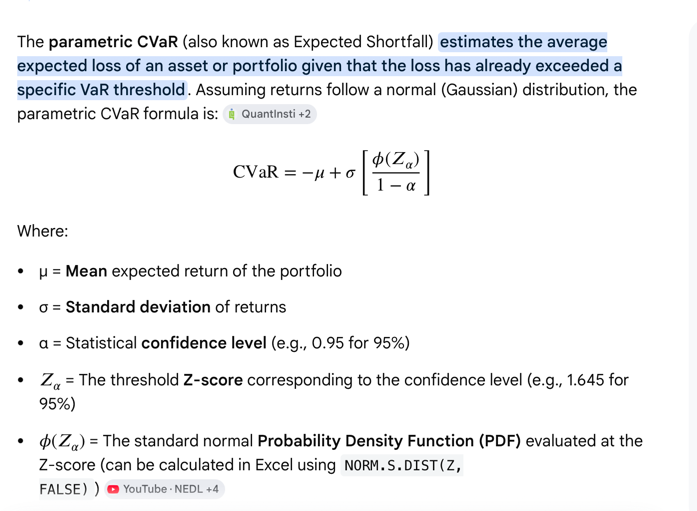

In [ ]:

# mean returns as expected value:
mu_vec = returns.mean().values

# covariance matrix::
e_cov = returns.cov().values


In [ ]:
mu_vec

In [ ]:
# multipyling mu_vec with weights to get single expected daily return
mu_p = mu_vec @ weights
mu_p
# we will use negated version of it ( -mu_p) to characterize expected daily LOSS

In [ ]:
e_cov

In [ ]:
portfolio_std_deviation = np.sqrt(weights @ e_cov @ weights) #we got coviarnace matrix (e_cov) from 02_monte_carlo.ipynb
portfolio_std_deviation

We calculated %1.44 daily volatility.

In [ ]:
Z_alpha = stats.norm.ppf(confidence  )
Z_alpha # normal quantile at %95

In [ ]:
phi_z = stats.norm.pdf(Z_alpha)
phi_z

In [ ]:
parametric_var = -mu_p + portfolio_std_deviation * Z_alpha
parametric_var

Historical VaR was % 1.9
Now we have recieved an parametric war of %2.29

**Parametric is higher -> more conservatice/expects a higher risks.**

The study material was pointing out that NORMAL EXPECTATION MIGHT UNEDERSTIMATE THE TAIL RISK.

In [ ]:
parametric_cvar = -mu_p + portfolio_std_deviation * (phi_z / (1 - confidence))
parametric_cvar

Historical CVAR was 0.0336 (%3.36), but parametric CVAR is 0.0289 (%2.89)

So even though tail threshold (VAR) was higher, average values at tail is smaller than the historical ones.

Normally, study material points out that *parametric VAR might be LESS CONSERVATIVE/LESSER than the historical one + might underestimate the risk. But there we had a opposed situation, and the severity has not contiuned at calculation at CVAR.

**So, an detailed analysis of kurtosis(tailedness) of distrubution might (according to Claude) help here**



In [ ]:
returns.kurtosis()

### Semi-Exkurs: Leptokurtic Distrubution

All four assets exhibit substantial positive excess kurtosis (a normal distribution has 0)  the
portfolio's return distribution is **leptokurtic**: a sharper, narrower peak around the mean, combined
with rare but extreme outliers in the tails.
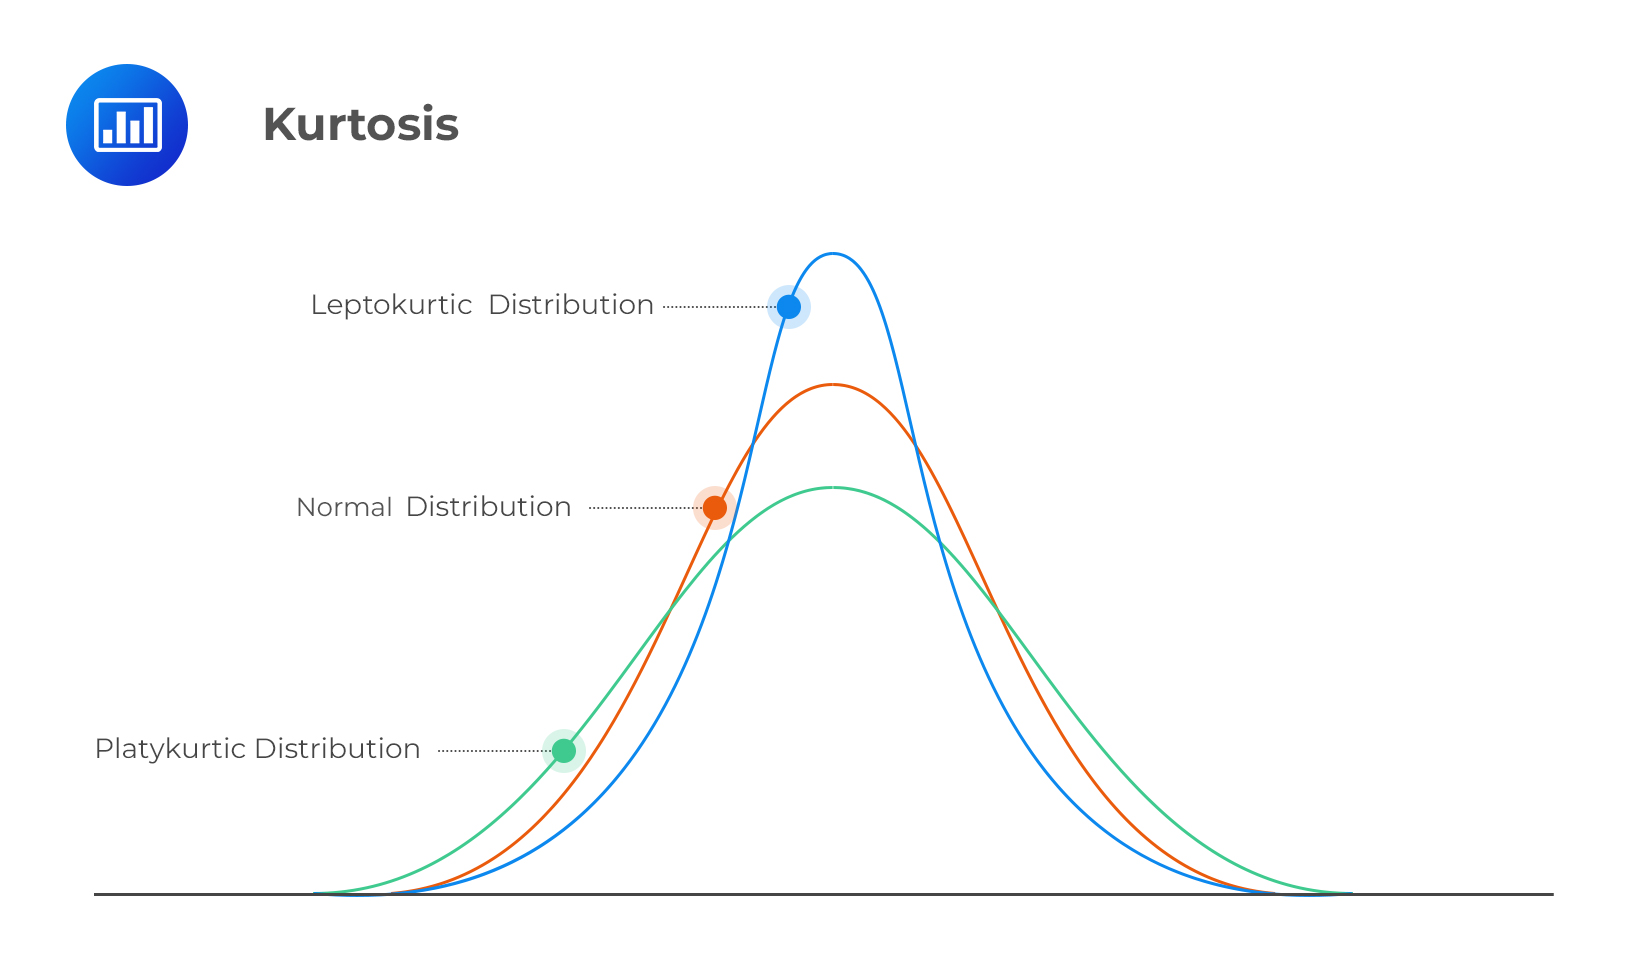

**Leptokurtic (blue, kurtosis > 0  our case):**
- A sharper, taller peak — values cluster more tightly around the mean (most days are "calm")
- The shoulders (just below the peak) sit **below** the normal curve
- The far tails (not visible here, but mathematically present) sit **above** the normal curve — rare
  but extreme events

**Normal (orange, kurtosis = 0):** the reference curve

**Platykurtic (green, kurtosis < 0):**
- A flatter, wider peak — values are more spread out around the mean



#### This shape distorts the normal model's parameters in two opposing directions:

1. **Variance is inflated by rare extreme events.** Since variance is computed by squaring deviations,
   a handful of large outlier days contribute disproportionately to $\sigma_p$. The result is a
   $\sigma_p$ that is too large relative to the "typical" day-to-day fluctuations of the portfolio.

2. **The normal distribution spreads this inflated $\sigma_p$ uniformly.** Parametric VaR
   ($Z_\alpha \cdot \sigma_p$) is computed using the same $\sigma_p$ that applies everywhere in the
   distribution — including the body. Because the true distribution's body is in fact narrower than a
   normal distribution with this $\sigma_p$ would suggest, the 95th-percentile threshold implied by the
   normal model ends up **overestimating** the true historical VaR.

3. **But the normal distribution's tails decay exponentially**, while the true (empirical) tail decays
   much more slowly. So while the normal model overstates the *threshold* (VaR), it cannot replicate the
   *severity* of the rare extreme losses that actually occurred historically — leading to an
   **underestimated** CVaR.

In short: high kurtosis inflates $\sigma_p$, which pushes parametric VaR above the historical value —
but the normal distribution's thin tails are structurally incapable of reproducing the magnitude of the
true extreme losses, so parametric CVaR falls short of the historical figure. The net effect is that the
normal model **misallocates risk**: it overstates the threshold for "bad days" while understating the
severity of "catastrophic days."


This motivates comparing against the **Student-t parametric model**, whose heavier tails (low degrees
of freedom $\nu$, consistent with the high kurtosis observed above) should bring both VaR and CVaR
closer to the historical figures.


##### Observing graphically whether the returns follow the leptokurtic shape:

In [ ]:
fig, ax = plt.subplots()
ax.set_yscale('log')
plt.hist(returns['XOM'], bins= 200)
ax.set_xlabel('XOM Returns')
plt.show()

In [29]:
returns['AAPL'].std()

np.float64(0.019955666718509714)